## This is to display the final version of the model

1. Define the mappings from the neuron index to the spatial space.

\begin{equation}
    \theta_k := - \frac\pi2 + \frac{k-k_1}{k_2-k_1}\pi \tag{1}
\end{equation}

2. Define the ideal solutions for the edge/bump attractor

\begin{equation}
r_{B,D}(\theta;\,\hat\theta) = r_0 \exp\left[-\frac{(\theta-\hat\theta)^2}{2a^2}\right] \tag{2}
\end{equation}

\begin{equation}
r_{E,D}(\theta;\,\hat\theta) \;=\; \exp\!\left[-e^{-s(\theta-\hat\theta)}\right] \tag{3}
\end{equation}

For the edge solution, notice we could anternatively assume a symmteric kernel to construct the connectivity matrix instead, and the solution is:
\begin{equation}
\tilde{r}_{E,D}(\theta;\,\hat\theta) \;=\; \sigma\left[-s'(\theta-\hat{\theta})\right]\tag{3}
\end{equation}
where $s'=\frac{4s}{e}$.


3. Map back to the index space:

\begin{align}
r_{B,D}[k;\hat k]
&= r_0 \exp\!\left[
-\frac{\pi^2}{2a^2\,(k_2-k_1)^2}\,(k-\hat k)^2
\right] \tag{4}\\[6pt]
r_{E,D}[k;\hat k]
&= 2\,\exp\!\left[
-\exp\!\left(
-\;s\,\frac{\pi}{\,k_2-k_1\,}\,(k-\hat k)
\right)\right]-1 \tag{5}
\end{align}
or
\begin{equation}
\tilde{r}_{E,D}[k;\hat k] = \sigma\left[-s' \frac{\pi}{k_2-k_1}(k-\hat k)\right]
\tag{6}
\end{equation}
where $\sigma$ is the sigmoid function.

Below we show that the network is caplable of reproducing the dynamics provided by eq 4. and eq 5.



In [1]:
import numpy as np
import brainpy as bp

import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model_rate_based import CANN_DDM_model
#from make_conn_mat import make_edge_conn_mat, make_bump_conn_mat
from make_conn_mat_updated import make_conn_mat_from_kernel
from tqdm import tqdm
import pickle
import seaborn as sns

In [17]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 5, 'c_EB': 5,
             'alpha_E': 1, 'sigma_E': 5, 'clamp_frac_E': 0.1, 
            'edge_type': 'tanh', 'offset': 0.0, 'optimize_offset': False,
            'k0':512}
#-0.006176
bump_pop = {'num_B': 1024, 'beta_B':4,
            'c_BE_params': {'mode': 'const'}, 
            'sigma_B': 0.1, 'clamp_frac_B': 0.1}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 1, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur': 1100, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)

  0%|          | 0/1100 [00:00<?, ?it/s]

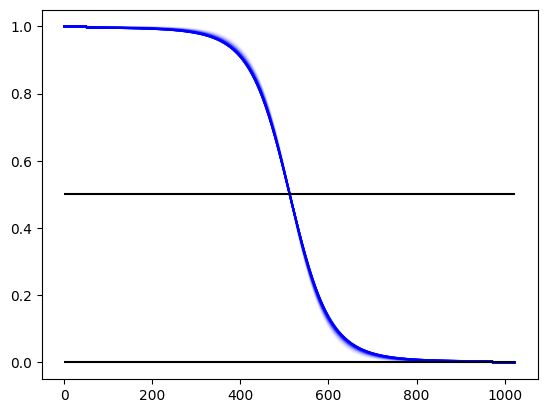

In [13]:
pos_offset = 0
decision_space_params.update({'seed': 2025})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)
runner = model.run_simulation(mon_vars = ['r_E', 'r_B', 'I_BE', 'I_EE'], pos_offset=pos_offset, get_RT=False)
r_E = runner.mon.r_E
r_B = runner.mon.r_B
I_BE = runner.mon.I_BE
I_EE = runner.mon.I_EE
for t in range(0, 200, 10):
    #plt.plot(I_BE[t,:])
    #plt.plot(I_EE[t,:], color='red')
    #plt.plot(model.phi_E(I_EE[t,:]), color='red')
    plt.plot(r_E[t,:], color='blue', alpha = t/300)
    #plt.plot(r_B[t,:])
    
plt.hlines(0.5, 0, 1024, color='black')
plt.hlines(0, 0, 1024, color='black')

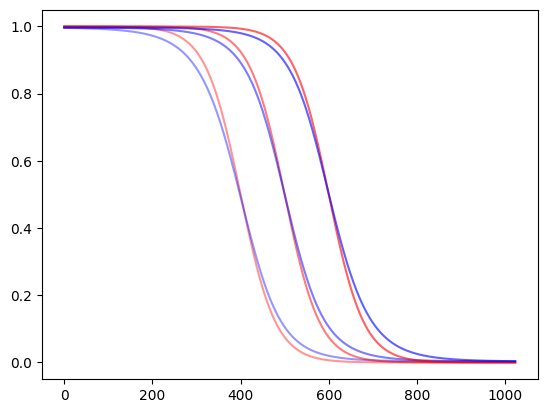

In [9]:

num_E = 1024; sigma_E = 5; clamp_frac_E = 0.1; k1 = int(num_E*(clamp_frac_E/2)); k2 = int(num_E*(1-clamp_frac_E/2))
beta = 0; k0 = 512
def sigmoid(x):
    return 1/(1+bm.exp(-x))
def edge_states(num, sigma, k0, k1, k2, edge_type='tanh'):
    """
    Calculate the edge states.
    if type is 'Laplace', r = exp(-exp(sigma*(bm.pi/(k2-k1))*(k-k0)))
    if type is 'tanh', r = sigmoid(-sigma_prime*bm.pi/(k2-k1) * (k-k0))
    """
    k = bm.arange(num)
    if edge_type == 'Laplace':
        return bm.exp(-bm.exp(sigma*(bm.pi/(k2-k1))*(k-k0)))
    elif edge_type == 'tanh':
        sigma_prime = 4 * sigma / bm.exp(1)
        return sigmoid(-sigma_prime*bm.pi/(k2-k1) * (k-k0))
    else:
        raise ValueError('Edge type should be either Laplace or tanh.')
    
def phi_E(x, alpha, beta):
    return sigmoid(alpha*x + beta)

beta = -np.sum(model.J_EE[512,:])/2
#beta = 0

for i, k0 in enumerate(bm.linspace(400, 600, 3)):
    r_E0 = edge_states(num_E, sigma_E, k0, k1, k2)
    plt.plot(r_E0, color='red', alpha = float(k0/k2))
    #plt.plot(1*(model.J_EE @ r_E0 + beta), color='blue', alpha = float(k0/k2))
    plt.plot(phi_E(model.J_EE @ r_E0, 1, beta), color='blue', alpha = float(k0/k2))

#plt.ylim(-0.1,1.1)

  0%|          | 0/1100 [00:00<?, ?it/s]

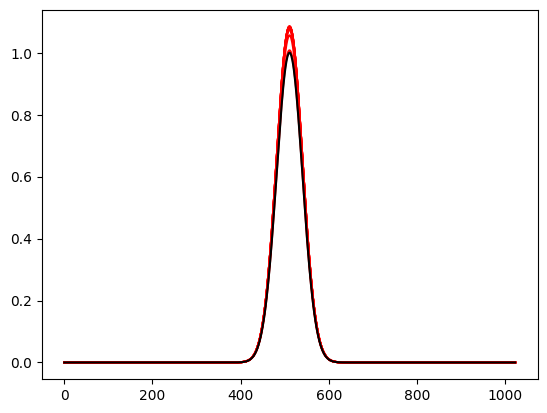

In [18]:
pos_offset = 0
decision_space_params.update({'seed': 2025})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)
runner = model.run_simulation(mon_vars = ['r_E', 'r_B', 'I_BE', 'I_EE', 'I_BB'], pos_offset=pos_offset, get_RT=False)
r_E = runner.mon.r_E
r_B = runner.mon.r_B
I_BE = runner.mon.I_BE
I_EE = runner.mon.I_EE
I_BB = runner.mon.I_BB
plt.figure()
for t in range(0, 100, 10):
    #plt.plot(I_BE[t,:])
    #plt.plot(I_EE[t,:], color='red')
    #plt.plot(model.phi_E(I_EE[t,:]), color='red')
    #plt.plot(r_E[t,:], color='blue', alpha = t/300)
    plt.plot(r_B[t,:], color='red')
    #plt.plot(I_BB[t,:], color='green')

plt.plot(model.r_B0, color='black')

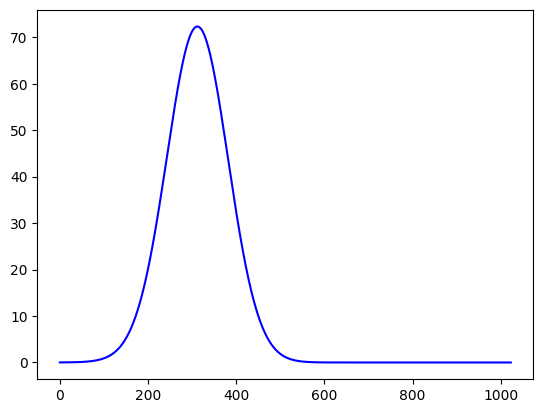

In [5]:
plt.plot(model.phi_B(I_BB[0,:]), color='blue')